# Hecof Bucket Embedding Clustering

This notebook loads `hecof_ntua_profiles.csv`, builds `cross_concept_avg_ability`, and runs `HecofBucketEmbeddingClusterOptimizer` .

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score

from hecof_bucket_embedding_cluster import HecofBucketEmbeddingClusterOptimizer

## Semantic-refined K-Means

In [ ]:
DATA_PATH = Path("hecof_ntua_profiles.csv")
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

client = OpenAI() #use your OPENAI_API_KEY 

def openai_bucket_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model=OPENAI_EMBEDDING_MODEL,
        input=text,
    )
    return np.array(response.data[0].embedding, dtype=float)

def get_kmeans(vectors):
    return KMeans(n_clusters=19, random_state=0, n_init="auto")

df = pd.read_csv(DATA_PATH)
profiles_df = df.copy()

mastery_columns = [
    column for column in profiles_df.columns
    if column.endswith("_masteryStatus")
]
ability_columns = [
    column for column in profiles_df.columns
    if column.endswith("_ability")
]


profiles_df[mastery_columns] = profiles_df[mastery_columns].replace(6, 1)
profiles_df[mastery_columns] = profiles_df[mastery_columns].replace(7, 1) ## I find 2 entrys are incorrectly (>5) in the raw dataset, justified by the ability they should be fallen back to 1.

profiles_df["cross_concept_avg_ability"] = profiles_df[ability_columns].mean(axis=1)

feature_columns = mastery_columns + ["cross_concept_avg_ability"]
profiles = profiles_df.to_dict(orient="records")
X = profiles_df[feature_columns].fillna(0.0).astype(float).to_numpy()

print("num learners:", len(profiles_df))
print("num mastery features:", len(mastery_columns))
print("feature columns:", len(feature_columns))



num learners: 31
num mastery features: 11
feature columns: 12


In [3]:

bucket_optimizer = HecofBucketEmbeddingClusterOptimizer(
    cluster_models=[get_kmeans],
    concept_embedding_fn=openai_bucket_embedding,
    small_cluster_size=10,
    verbose=False,
)

X_scaled = bucket_optimizer._build_feature_matrix(
    profiles,
    feature_columns,
)

bucket_labels, bucket_clusters = bucket_optimizer.fit_predict_profiles(
    profiles,
    feature_columns=feature_columns,
)


final_semantic_score = bucket_optimizer._default_calculate_clustering_score(bucket_clusters)
final_silhouette_score = float(silhouette_score(X_scaled, bucket_labels))



num_clusters = len(np.unique(bucket_labels))


if num_clusters > 1:
    print("final_clusters:", int(len(np.unique(bucket_labels))))
    print("final_semantic_score:", round(final_semantic_score, 4))
    print("final_silhouette_score:", round(final_silhouette_score, 4))
else:
    print("Only one cluster found; silhouette and Davies-Bouldin are undefined.")

/home/ivan/anaconda3/envs/vrqa/lib/python3.12/site-packages/sklearn/cluster/_affinity_propagation.py:50: UserWarning: All samples have mutually equal similarities. Returning arbitrary cluster center(s).
  warnings.warn(


final_clusters: 4
final_semantic_score: 0.4882
final_silhouette_score: 0.3345


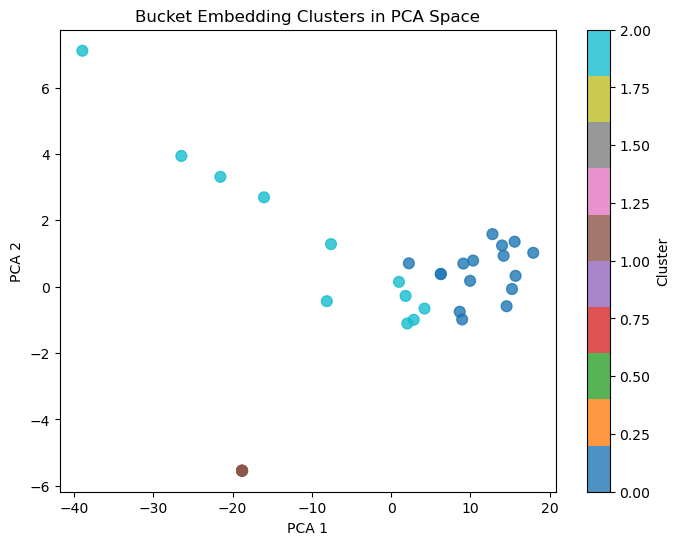

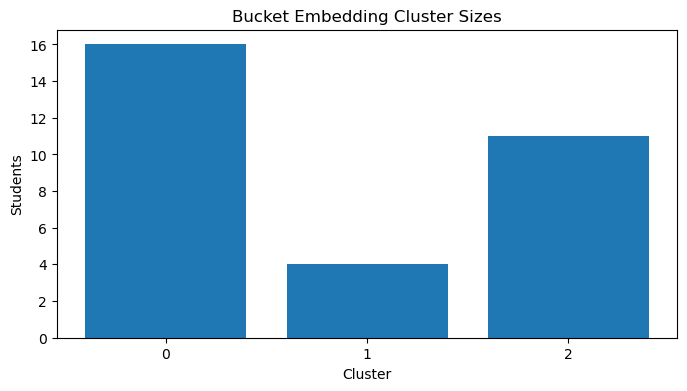

In [19]:
pca = PCA(n_components=2, random_state=0)
pca_coords = pca.fit_transform(X)

viz_df = profiles_df[["student_id", "cross_concept_avg_ability", "bucket_embedding_cluster"]].copy()
viz_df["pca_1"] = pca_coords[:, 0]
viz_df["pca_2"] = pca_coords[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    viz_df["pca_1"],
    viz_df["pca_2"],
    c=viz_df["bucket_embedding_cluster"],
    cmap="tab10",
    s=60,
    alpha=0.8,
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Bucket Embedding Clusters in PCA Space")
plt.colorbar(scatter, label="Cluster")
plt.show()

cluster_sizes = viz_df["bucket_embedding_cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel("Cluster")
plt.ylabel("Students")
plt.title("Bucket Embedding Cluster Sizes")
plt.show()


In [58]:
def build_bucket_cluster_payload(cluster):
    feature_stats = bucket_optimizer._get_cluster_feature_stats(cluster, feature_columns)
    return {
        "label": int(cluster.label),
        "num_students": len(cluster),
        "concept": feature_stats["concept"],
        "ability": feature_stats["ability"],
    }

bucket_cluster_payload = [
    build_bucket_cluster_payload(cluster)
    for cluster in sorted(bucket_clusters, key=lambda cluster: cluster.label)
]

print(json.dumps(bucket_cluster_payload, indent=2))


[
  {
    "label": 0,
    "num_students": 2,
    "concept": {
      "not_started_concepts": {
        "items": [],
        "value": null
      },
      "just_started_concepts": {
        "items": [],
        "value": null
      },
      "struggle_concepts": {
        "items": [
          "Conventional extraction techniques",
          "Experiment Extraction at large scale at Industry",
          "Experiment Extraction of Olive-based compounds",
          "Extraction yield and mathematical modelling",
          "Factors influencing extraction",
          "Innovative extraction techniques",
          "Introduction Extraction of olive-based compounds",
          "Solid-Liquid Extraction Mechanism",
          "Solvents and processing conditions"
        ],
        "value": 2.0
      },
      "good_concepts": {
        "items": [
          "Introduction to extraction process",
          "Solid-Liquid Extraction Definition"
        ],
        "value": 3.0
      },
      "strong_concepts": {


In [21]:
summary_prompt = f"""
You are an expert educational coach helping a teacher interpret learner clusters for the topic of solid-liquid extraction.

Each cluster represents a group of learners based on:
1. concept-level mastery buckets:
   - not_started_concepts: learners have not yet engaged with these concepts
   - just_started_concepts: learners have begun but show limited progress
   - struggle_concepts: learners show difficulty and need support
   - good_concepts: learners show developing or adequate understanding
   - strong_concepts: learners show strong understanding

2. cross-concept average ability:
   - low_ability
   - medium_ability
   - high_ability

Your task is to produce a teacher-facing interpretation for each cluster and recommend exactly one teaching action from the following set:

- onboarding: use when the group has many not_started concepts and needs introductory instruction, initial concept exposure, orientation to the topic, or foundational learning activities.
- revision: use when the group has previously encountered the concepts but shows broad foundational gaps, many struggle concepts, or low mastery across several areas.
- guided-mastery: use when the group has specific struggle concepts but enough prior knowledge to improve through structured support, worked examples, scaffolding, or targeted practice.
- think-pair-share: use when the group has good or strong understanding and can benefit from discussion, peer explanation, application, comparison, or extension tasks.

For each cluster, provide:
1. Group profile: a concise description of the learner group.
2. Key learning needs: the main concepts or patterns the teacher should notice.
3. Recommended teaching action: choose exactly one from {{onboarding, revision, guided-mastery, think-pair-share}}.
4. Rationale: briefly explain why this action fits the cluster.
5. Suggested teacher move: give one concrete classroom action.

Important constraints:
- Use clear teacher-facing language.
- Do not change the cluster labels, number of students, or bucket assignments.
- Do not invent concepts that are not present in the input.
- Avoid overly generic advice.
- Keep each cluster interpretation concise.
- Base the recommendation on both concept mastery and ability level.
- If a cluster is dominated by not_started concepts, prefer onboarding.
- If a cluster has low ability and many struggle concepts, prefer revision.
- If a cluster has a small number of struggle concepts but otherwise good or strong mastery, prefer guided-mastery.
- If a cluster has mostly good or strong concepts and medium or high ability, prefer think-pair-share unless there are unresolved struggle concepts requiring targeted support.
- Do not confuse onboarding with revision: onboarding is for initial concept exposure, while revision is for reviewing or repairing previously attempted learning.

Input clusters:
{json.dumps(bucket_cluster_payload, indent=2)}

Output format:

Cluster <label> (<num_students> students) : <ability_level>
- Group profile:
- Key learning needs:
- Recommended teaching action:
- Rationale:
- Suggested teacher move:
"""

response = client.chat.completions.create(
    model="gpt-5-nano",
    messages=[{"role": "user", "content": summary_prompt}]
)

print(response.choices[0].message.content)


Cluster 0 (16 students) : medium_ability
- Group profile:
  Learners show strong and good mastery across many solid-liquid extraction concepts, with one clear gap in scaling to industrial context ("Experiment Extraction at large scale at Industry").
- Key learning needs:
  Bridge lab-level understanding to industrial-scale extraction; integrate scaling, processing conditions, and industry-relevant considerations with existing strong concepts.
- Recommended teaching action:
  guided-mastery
- Rationale:
  The group has a small set of unresolved struggle concepts amid extensive strong/good mastery, making targeted, structured support appropriate.
- Suggested teacher move:
  Use a scaffolded session with a worked example of translating a lab extraction to an industrial-scale process (solvent choices, solid-to-liquid ratios, temperature, residence time, throughput), followed by guided practice and feedback.

Cluster 1 (4 students) : medium_ability
- Group profile:
  All major concepts are 

In [22]:
rubric = """
You are an expert evaluator of teacher-facing learning analytics explanations.

Your task is to evaluate an LLM-generated cluster interpretation and teaching recommendation against the structured cluster input. The response should help a teacher understand each learner group and select an appropriate teaching action.

The allowed teaching actions are:
- onboarding
- revision
- guided-mastery
- think-pair-share

Evaluate the response using the following rubric. Assign a score from 1 to 5 for each criterion, where:
1 = poor
2 = weak
3 = acceptable
4 = good
5 = excellent

Criteria:

1. Faithfulness to cluster data
- 5: Accurately reflects the given cluster labels, number of students, mastery buckets, ability levels, and concept distributions without adding unsupported claims.
- 3: Mostly accurate, with minor omissions or small generalizations.
- 1: Misrepresents cluster contents, invents concepts, changes labels, or contradicts the input data.

2. Pedagogical interpretation
- 5: Clearly explains what each cluster means in teacher-facing language, linking mastery patterns and ability levels to learner needs.
- 3: Provides a reasonable but somewhat generic interpretation.
- 1: Gives vague, unclear, or technically correct but pedagogically unhelpful descriptions.

3. Appropriateness of teaching action
- 5: Selects a suitable action from {{onboarding, revision, guided-mastery, think-pair-share}} for each cluster based on both mastery buckets and ability level.
- 3: Selects mostly reasonable actions, but some choices are weakly justified or only partially aligned.
- 1: Selects inappropriate actions, ignores the allowed action set, or confuses the purpose of different actions.

Teaching action guidance:
- onboarding: appropriate when a cluster is dominated by not_started concepts and requires introductory instruction, initial concept exposure, or orientation to the topic.
- revision: appropriate when learners appear to have previously encountered the content but show broad struggle, low mastery, or foundational gaps across several concepts.
- guided-mastery: appropriate when learners have specific struggle concepts but sufficient prior knowledge to improve through scaffolding, worked examples, and targeted practice.
- think-pair-share: appropriate when learners have mostly good or strong mastery and can benefit from peer explanation, discussion, application, or extension tasks.

4. Distinction between onboarding and revision
- 5: Clearly distinguishes not_started learners who need onboarding from struggling learners who need revision.
- 3: Makes a reasonable distinction, but the explanation is somewhat implicit or inconsistent.
- 1: Treats not_started and struggle patterns as the same learning need, or recommends revision when onboarding is clearly more appropriate.

5. Quality of rationale
- 5: Provides a concise and convincing explanation for why the selected action fits the cluster profile.
- 3: Provides some rationale, but it is generic or incomplete.
- 1: Provides little or no rationale, or the rationale does not match the data.

6. Actionability for teachers
- 5: Gives concrete, practical teaching moves that a teacher could apply directly.
- 3: Gives usable but broad teaching suggestions.
- 1: Gives abstract, impractical, or non-instructional advice.

7. Differentiation across clusters
- 5: Clearly distinguishes the needs of different clusters and avoids giving the same generic recommendation to all groups.
- 3: Shows some differentiation, but several groups are treated similarly.
- 1: Fails to distinguish clusters meaningfully.

8. Clarity and conciseness
- 5: Uses clear, concise, teacher-facing language with no unnecessary technical detail.
- 3: Understandable but slightly verbose, repetitive, or uneven.
- 1: Difficult to read, overly technical, or poorly organized.

Overall judgment:
After scoring each criterion, provide:
- Total score out of 40
- Normalized score from 0 to 1
- Overall quality rating:
  - 34--40: Excellent
  - 28--33: Good
  - 21--27: Acceptable
  - 14--20: Weak
  - 8--13: Poor
- A short justification of the rating
- One suggestion for improvement

Important evaluation rules:
- Do not reward unsupported information that is not grounded in the cluster input.
- Do not require long responses; concise teacher-facing explanations should be rewarded if they are accurate and useful.
- Penalize recommendations that ignore the allowed action set.
- Penalize responses that confuse onboarding with revision.
- Penalize responses that confuse high ability with no learning need; high-ability clusters may still require targeted support for struggle concepts.
- Penalize responses that treat all struggle concepts equally without considering the number of concepts, ability level, and overall mastery profile.
- Reward responses that distinguish between learners who have not started the content and learners who have attempted the content but are struggling.

Expected action tendencies:
- Use onboarding when learners have many not_started concepts and need introductory instruction.
- Use revision when learners have low ability or broad struggle across many concepts.
- Use guided-mastery when learners have a small number of struggle concepts but otherwise good or strong prior knowledge.
- Use think-pair-share when learners have mostly good or strong mastery and can benefit from peer discussion, explanation, or application.
"""

eval_prompt = f"""
You are an expert evaluator of teacher-facing learning analytics explanations.

Evaluate the following LLM-generated cluster summary against the original cluster data using the rubric below.

Original cluster data:
{bucket_cluster_payload}

Generated summary response:
{response}

Rubric:
{rubric}

Return:
1. Scores for each criterion
2. Total score
3. Normalized score
4. Overall rating
5. Brief justification
6. One improvement suggestion
"""

eval_response = client.chat.completions.create(
    model="gpt-5",
    messages=[{"role": "user", "content": eval_prompt}]
)

print(eval_response.choices[0].message.content)


1) Scores
- Faithfulness to cluster data: 4
- Pedagogical interpretation: 5
- Appropriateness of teaching action: 5
- Distinction between onboarding and revision: 5
- Quality of rationale: 5
- Actionability for teachers: 5
- Differentiation across clusters: 5
- Clarity and conciseness: 5

2) Total score
- 39 / 40

3) Normalized score
- 0.975

4) Overall quality rating
- Excellent

5) Justification
- The summary accurately reports labels, group sizes, and overall mastery/ability patterns and gives clear, teacher-facing interpretations with concrete next steps. Teaching actions are well matched: onboarding for the all–not-started group, guided-mastery for groups with targeted struggles. Minor faithfulness issues: Cluster 2 is described as having “good/strong” mastery despite no “strong” concepts in the data, and Cluster 0’s needs mention integrating “processing conditions” even though that concept is already strong.

6) One suggestion for improvement
- Calibrate descriptions precisely to

## Pure kmeans

In [ ]:
# Pure KMeans baseline on the same fixed-scaled feature matrix used by the optimizer.
pure_kmeans_X_scaled = bucket_optimizer._build_feature_matrix(
    profiles,
    feature_columns,
)

pure_kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
pure_kmeans_labels = pure_kmeans.fit_predict(pure_kmeans_X_scaled)

profiles_df["pure_kmeans_cluster"] = pure_kmeans_labels

print("silhouette_score:", round(silhouette_score(pure_kmeans_X_scaled, pure_kmeans_labels), 4))
print("davies_bouldin_score:", round(davies_bouldin_score(pure_kmeans_X_scaled, pure_kmeans_labels), 4))
profiles_df[["student_id", "pure_kmeans_cluster"]].head()

from hecof_llm_cluster import SummarizedProfileCluster

pure_kmeans_clusters = []
pure_kmeans_summary = []
for cluster_label in sorted(np.unique(pure_kmeans_labels)):
    cluster_profile_frame = profiles_df.loc[
        profiles_df["pure_kmeans_cluster"] == cluster_label
    ]
    cluster_profiles = cluster_profile_frame.to_dict(orient="records")
    cluster_vectors = pure_kmeans_X_scaled[cluster_profile_frame.index]
    cluster = SummarizedProfileCluster(
        label=int(cluster_label),
        member_indices=list(cluster_profile_frame.index),
        vectors=[row for row in cluster_vectors],
        profiles=cluster_profiles,
    )
    pure_kmeans_clusters.append(cluster)

bucket_optimizer._active_feature_columns = list(feature_columns)
pure_kmeans_clusters = bucket_optimizer._summarize_clusters(
    pure_kmeans_clusters,
    feature_columns=feature_columns,
)
pure_kmeans_clustering_score = bucket_optimizer._default_calculate_clustering_score(
    pure_kmeans_clusters,
)

for cluster in pure_kmeans_clusters:
    feature_stats = bucket_optimizer._get_cluster_feature_stats(cluster, feature_columns)
    pure_kmeans_summary.append({
        "label": int(cluster.label),
        "num_students": len(cluster),
        "concept": feature_stats["concept"],
        "ability": feature_stats["ability"],
    })

print("pure_kmeans_clustering_score:", round(pure_kmeans_clustering_score, 4))
print(json.dumps(pure_kmeans_summary, indent=2))


silhouette_score: 0.6605
davies_bouldin_score: 0.2609
pure_kmeans_clustering_score: 0.4773
[
  {
    "label": 0,
    "num_students": 27,
    "concept": {
      "not_started_concepts": {
        "items": [],
        "value": null
      },
      "just_started_concepts": {
        "items": [],
        "value": null
      },
      "struggle_concepts": {
        "items": [
          "Experiment Extraction at large scale at Industry"
        ],
        "value": 2
      },
      "good_concepts": {
        "items": [
          "Experiment Extraction of Olive-based compounds",
          "Innovative extraction techniques"
        ],
        "value": 3.0
      },
      "strong_concepts": {
        "items": [
          "Conventional extraction techniques",
          "Extraction yield and mathematical modelling",
          "Factors influencing extraction",
          "Introduction Extraction of olive-based compounds",
          "Introduction to extraction process",
          "Solid-Liquid Extraction

In [17]:
from hecof_llm_cluster import SummarizedProfileCluster

pure_kmeans_clusters = []
pure_kmeans_summary = []
for cluster_label in sorted(np.unique(pure_kmeans_labels)):
    cluster_profile_frame = profiles_df.loc[
        profiles_df["pure_kmeans_cluster"] == cluster_label
    ]
    cluster_profiles = cluster_profile_frame.to_dict(orient="records")
    cluster_vectors = pure_kmeans_X_scaled[cluster_profile_frame.index]
    cluster = SummarizedProfileCluster(
        label=int(cluster_label),
        member_indices=list(cluster_profile_frame.index),
        vectors=[row for row in cluster_vectors],
        profiles=cluster_profiles,
    )
    pure_kmeans_clusters.append(cluster)

bucket_optimizer._active_feature_columns = list(feature_columns)
pure_kmeans_clusters = bucket_optimizer._summarize_clusters(
    pure_kmeans_clusters,
    feature_columns=feature_columns,
)
pure_kmeans_clustering_score = bucket_optimizer._default_calculate_clustering_score(
    pure_kmeans_clusters,
)

for cluster in pure_kmeans_clusters:
    feature_stats = bucket_optimizer._get_cluster_feature_stats(cluster, feature_columns)
    pure_kmeans_summary.append({
        "label": int(cluster.label),
        "num_students": len(cluster),
        "concept": feature_stats["concept"],
        "ability": feature_stats["ability"],
    })

print("pure_kmeans_clustering_score:", round(pure_kmeans_clustering_score, 4))
print(json.dumps(pure_kmeans_summary, indent=2))


summarize profile clusters: 100%|██████████| 4/4 [00:00<00:00, 1514.33it/s]

Cluster summary | size=10 | summary=cluster_size=10
median_cross_concept_avg_ability_bucket=high_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=none
strong_concepts=Solid-Liquid Extraction Definition|Solid-Liquid Extraction Mechanism|Solvents and processing conditions|Conventional extraction techniques
Cluster summary | size=4 | summary=cluster_size=4
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=Conventional extraction techniques|Experiment Extraction at large scale at Industry|Experiment Extraction of Olive-based compounds|Extraction yield and mathematical modelling
just_started_concepts=none
struggle_concepts=none
good_concepts=none
strong_concepts=none
Cluster summary | size=5 | summary=cluster_size=5
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Conventional extraction techniques

In [21]:
pure_kmeans_score_rows = []
bucket_optimizer._active_feature_columns = list(feature_columns)

for n_clusters in range(2, 32):
    if n_clusters >= len(profiles):
        continue

    trial_model = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    trial_labels = trial_model.fit_predict(pure_kmeans_X_scaled)
    trial_clusters = []

    for cluster_label in sorted(np.unique(trial_labels)):
        cluster_profile_frame = profiles_df.loc[trial_labels == cluster_label]
        cluster_profiles = cluster_profile_frame.to_dict(orient="records")
        cluster_vectors = pure_kmeans_X_scaled[cluster_profile_frame.index]
        cluster = SummarizedProfileCluster(
            label=int(cluster_label),
            member_indices=list(cluster_profile_frame.index),
            vectors=[row for row in cluster_vectors],
            profiles=cluster_profiles,
        )
        trial_clusters.append(cluster)

    trial_clusters = bucket_optimizer._summarize_clusters(
        trial_clusters,
        feature_columns=feature_columns,
    )
    trial_score = bucket_optimizer._default_calculate_clustering_score(
        trial_clusters,
    )

    row = {
        "n_clusters": int(n_clusters),
        "clustering_score": float(trial_score),
    }
    if 1 < len(np.unique(trial_labels)) < len(trial_labels):
        row["silhouette_score"] = float(silhouette_score(pure_kmeans_X_scaled, trial_labels))
        row["davies_bouldin_score"] = float(davies_bouldin_score(pure_kmeans_X_scaled, trial_labels))
    pure_kmeans_score_rows.append(row)

pure_kmeans_score_df = pd.DataFrame(pure_kmeans_score_rows).sort_values("n_clusters").reset_index(drop=True)
pure_kmeans_score_df


summarize profile clusters: 100%|██████████| 2/2 [00:00<00:00, 583.27it/s]

Cluster summary | size=27 | summary=cluster_size=27
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=Experiment Extraction of Olive-based compounds|Innovative extraction techniques
strong_concepts=Conventional extraction techniques|Extraction yield and mathematical modelling|Factors influencing extraction|Introduction Extraction of olive-based compounds
Cluster summary | size=4 | summary=cluster_size=4
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=Conventional extraction techniques|Experiment Extraction at large scale at Industry|Experiment Extraction of Olive-based compounds|Extraction yield and mathematical modelling
just_started_concepts=none
struggle_concepts=none
good_concepts=none
strong_concepts=none


summarize profile clusters: 100%|██████████| 3/3 [00:00<00:00, 524.70it/s]


Cluster summary | size=16 | summary=cluster_size=16
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=Experiment Extraction of Olive-based compounds
strong_concepts=Conventional extraction techniques|Extraction yield and mathematical modelling|Factors influencing extraction|Innovative extraction techniques
Cluster summary | size=4 | summary=cluster_size=4
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=Conventional extraction techniques|Experiment Extraction at large scale at Industry|Experiment Extraction of Olive-based compounds|Extraction yield and mathematical modelling
just_started_concepts=none
struggle_concepts=none
good_concepts=none
strong_concepts=none
Cluster summary | size=11 | summary=cluster_size=11
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=none
st

summarize profile clusters: 100%|██████████| 4/4 [00:00<00:00, 996.45it/s]


...

summarize profile clusters: 100%|██████████| 28/28 [00:00<00:00, 1928.32it/s]
/home/ivan/anaconda3/envs/vrqa/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (28) found smaller than n_clusters (30). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Cluster summary | size=1 | summary=cluster_size=1
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=Experiment Extraction of Olive-based compounds
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=none
strong_concepts=Conventional extraction techniques|Extraction yield and mathematical modelling|Factors influencing extraction|Innovative extraction techniques
Cluster summary | size=1 | summary=cluster_size=1
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=Experiment Extraction of Olive-based compounds
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=Conventional extraction techniques|Extraction yield and mathematical modelling|Factors influencing extraction|Innovative extraction techniques
strong_concepts=Introduction Extraction of olive-based compounds|Introduction to extraction process|Solid-Liquid Extraction Mechani

summarize profile clusters: 100%|██████████| 28/28 [00:00<00:00, 2282.79it/s]


Cluster summary | size=1 | summary=cluster_size=1
median_cross_concept_avg_ability_bucket=high_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Experiment Extraction at large scale at Industry
good_concepts=none
strong_concepts=Conventional extraction techniques|Experiment Extraction of Olive-based compounds|Extraction yield and mathematical modelling|Factors influencing extraction
Cluster summary | size=4 | summary=cluster_size=4
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=Conventional extraction techniques|Experiment Extraction at large scale at Industry|Experiment Extraction of Olive-based compounds|Extraction yield and mathematical modelling
just_started_concepts=none
struggle_concepts=none
good_concepts=none
strong_concepts=none
Cluster summary | size=1 | summary=cluster_size=1
median_cross_concept_avg_ability_bucket=medium_ability
not_started_concepts=none
just_started_concepts=none
struggle_concepts=Conventional extra

,n_clusters,clustering_score,silhouette_score,davies_bouldin_score
0,2,0.477273,0.660536,2.609254e-01
1,3,0.264330,0.467753,7.162041e-01
2,4,0.310585,0.399375,8.239699e-01
3,5,0.266743,0.351674,8.943837e-01
4,6,0.240851,0.361700,6.711648e-01
5,7,0.211288,0.360971,9.631657e-01
6,8,0.162393,0.274180,8.955450e-01
7,9,0.156397,0.257290,1.021738e+00
8,10,0.150169,0.276532,8.357106e-01
9,11,0.138603,0.295588,7.526214e-01
